### Ground and Space radio observations of the same event with RadioSpectra

This notebook demonstrates the use of [RadioSpectra](https://github.com/sunpy/radiospectra) to download, load and plot an individual radio event observed across ground and space-based observatories.

Installation/Environment Notes

In [1]:
### Basic Imports
from radiospectra import net
from sunpy.net import Fido, attrs as a
from radiospectra.spectrogram import Spectrogram
from radiospectra.net import attrs as ra
import datetime
import numpy as np
import astropy.table
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

/home/sbadman/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


We will download and load data from a very complex Type II,III,IV radio burst event which occurred around 16:40UT 2025/5/14. Various papers have been published on this event including: [Nedal et al. 2026](https://ui.adsabs.harvard.edu/abs/2026A%26A...708A..74N/abstract)

In [2]:
# Define start and end times to load
dt_start = datetime.datetime(2024,5,14,16,30)
dt_end = datetime.datetime(2024,5,14,19)

#### Accessing I-Lofar Data

RadioSpectra provides a `sunpy.net.Fido` client to search and download I-Lofar FITS dynamic spectrum data from this repository: https://lofar.ie/data-format/ with standard usage:

In [3]:
### I-LOFAR
query = Fido.search(a.Time(dt_start,dt_end),
                   a.Instrument('ILOFAR'), 
                   )
query

<sunpy.net.fido_factory.UnifiedResponse object at 0x7dd877e08850>
Results from 1 Provider:

0 Results from the ILOFARMode357Client:

<No columns>

Unfortunately for this particular event, the file we need is in different sub-folder to where the iLOFAR client currently checks. As of May 21 2026, a [GitHub issue](https://github.com/sunpy/radiospectra/issues/200) is open to enable Fido to check the other subdirectory.

If the query was successful, the file could be downloaded with Fido.fetch as:

In [4]:
# ilofar_files = Fido.fetch(query)

For the present use-case, we will assume a user has manually downloaded the file to the sample_data subfolder in this repository. The url for this file (~130MB) is : 

https://data.lofar.ie/2024/05/14/bst/kbt/rcu357_1beam_datastream_fast/20240514_100136_bst_00X.dat 

### Read the i-LOFAR data

Once the FITS file is available locally, it can be read directly with the `radiospectra.Spectrogram` container as: 

In [5]:
# Here we provide a path manually
ilofar_Spectrograms = Spectrogram("./sample_data/20240514_100136_bst_00X.dat")

If the Fido query was successful, this manual filepath specification could be avoided and instead the file loaded into your session with the following commented out line.

In [6]:
# ilofar_Spectrograms = Spectrogram(ilofar_files)

#### Plot the i-LOFAR data

With the i-LOFAR data parsed into the notebook, it can simply be plotted under default settings as:

(19857.6875, 19857.791666666668)

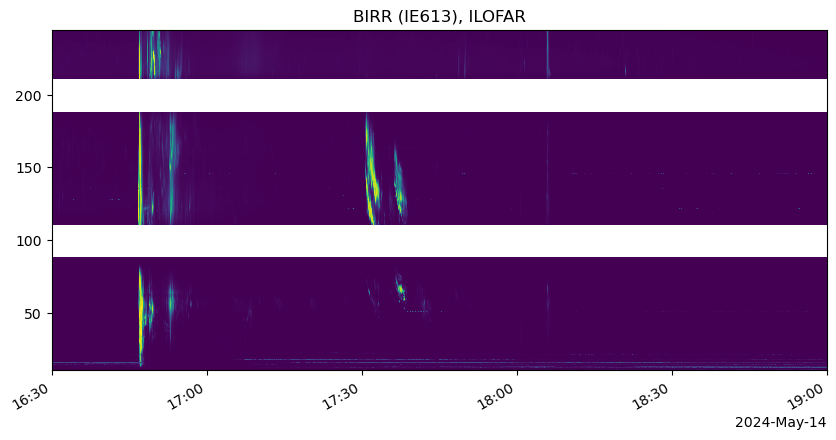

In [7]:
fig,ax = plt.subplots(figsize=(10,5))
[spec.plot(axes=ax) for spec in ilofar_Spectrograms] #plot in loop in case multiple Spectrograms were loaded
ax.set_xlim(dt_start,dt_end)

With regular `matplotlib` commands, the event structure can be better emphasized: 

(10, 200)

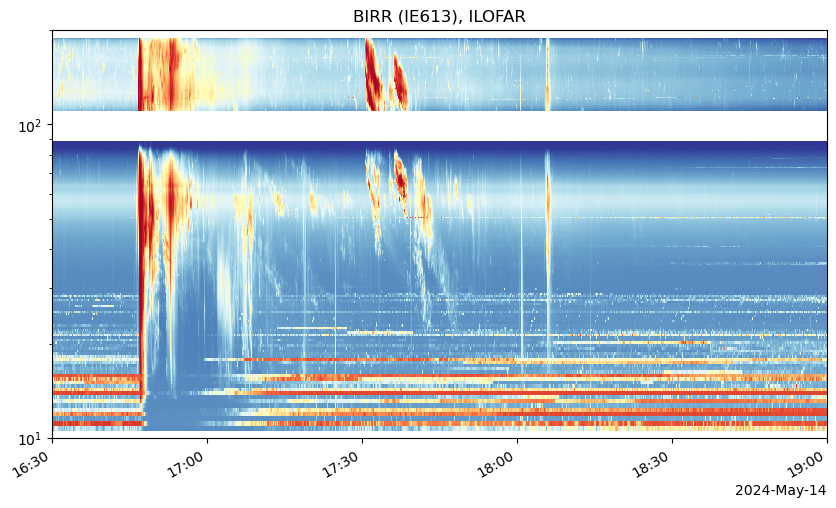

In [8]:
fig,ax = plt.subplots(figsize=(10,6))
[spec.plot(axes=ax,
           norm=LogNorm(spec.data.min(),spec.data.max()), # Log-Normalize Colorscale
           cmap="RdYlBu_r") # Colormap from Nedat+2026
 for spec in ilofar_Spectrograms]
ax.set_xlim(dt_start,dt_end)
ax.set_yscale("log")
ax.set_ylim(10,200)

So we can see what the event looked like low in the corona (~10-200 MHz), but what about out in space?

### Querying, Downloading and Plotting Parker Solar Probe FIELDS/RFS data

Staying within the `radiospectra` ecosystem, we can easily perform the same download/load/plot steps for Parker Solar Probe RFS instead (see also: `./psp_analysis.ipynb` and `./plot_psp.ipynb` in this directrory).

First: query the RFS data:

In [9]:
### FIELDS/RFS L2 Data 

query = Fido.search(a.Time(dt_start,dt_end),a.Instrument("rfs"))
query

### Note: L3 RFS data can be accessed via CDAWEB, but these files are not yet handled by `radiospectra`

# query = Fido.search(a.Time(dt_start,dt_end),
#                     (a.cdaweb.Dataset("PSP_FLD_L3_RFS_HFR") | # Note that RFS has two frequency bands, hfr and lfr
#                      a.cdaweb.Dataset("PSP_FLD_L3_RFS_LFR")   # Therefore we query both for the same date
#                     ))
# query  

# print(a.cdaweb.Dataset) ### to see the full list of available Datasets Fido can query                  

Start Time,End Time,Instrument,Source,Provider,Wavelength
,,,,,kHz
Time,Time,str3,str3,str4,float64[2]
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,RFS,PSP,SPDF,10.0 .. 1700.0
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,RFS,PSP,SPDF,1300.0 .. 19200.0


Note that RFS files are daily, we will therefore load a whole days data and only plot a subset of it.

Next download with Fido:

In [10]:
rfs_files = Fido.fetch(query)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Load in the RFS files by passing the downloaded files to `radiospectra.Spectrogram` :

In [11]:
rfs_Spectrograms = Spectrogram(rfs_files)

Next, plot the RFS data we loaded:

(Note that this plots two spectrograms (RFS HFR and RFS LFR) on the same axes.)

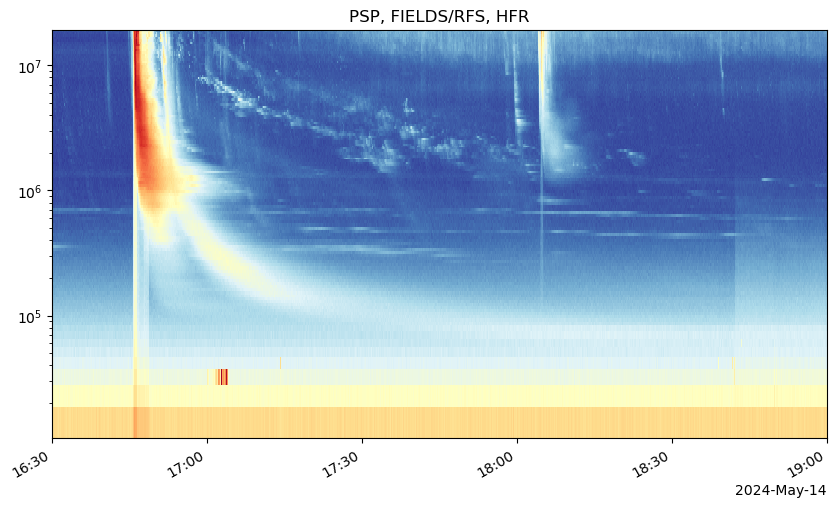

In [12]:
fig,ax = plt.subplots(figsize=(10,6))
[spec.plot(axes=ax,
           norm=LogNorm(spec.data.value.min(),spec.data.value.max()), # Log-Normalize Colorscale
           cmap="RdYlBu_r") # Colormap from Nedat+2026
 for spec in rfs_Spectrograms]
ax.set_xlim(dt_start,dt_end)
ax.set_yscale("log")

### Combining Ground and Space Observations of the Same Event

Finally, we can combine these plots to show the progression of the event from the low corona out into the solar wind.

The most straightforward way to do this is to just create two subplots, which avoids issues with units:

Text(0, 0.5, 'Frequency (Hz)')

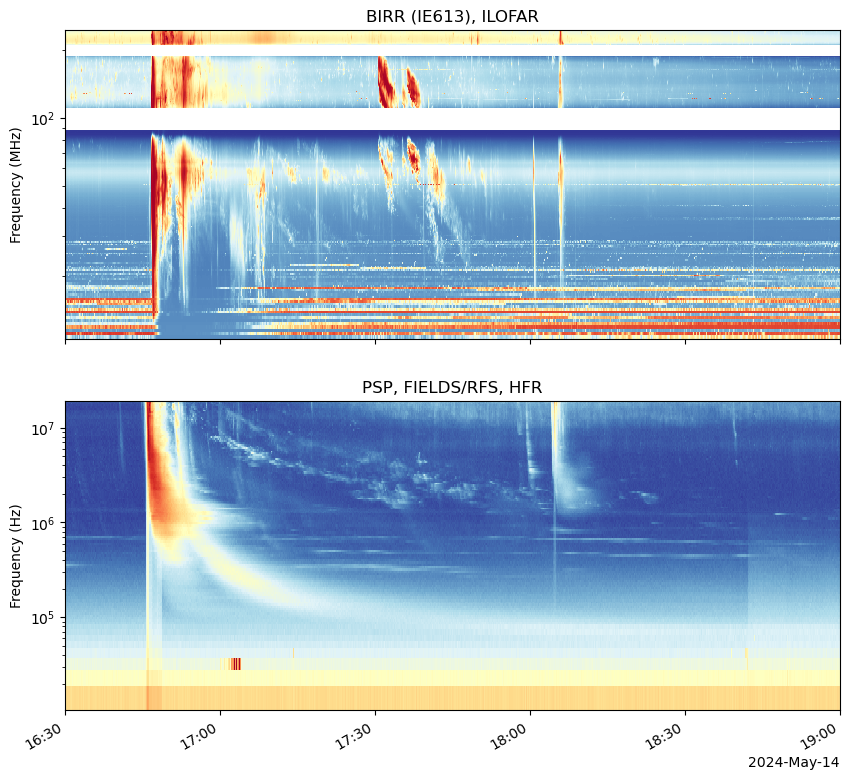

In [13]:
fig,(ax1,ax2) = plt.subplots(figsize=(10,10),nrows=2,sharex=True)

[spec.plot(axes=ax1,
           norm=LogNorm(spec.data.min(),spec.data.max()), # Log-Normalize Colorscale
           cmap="RdYlBu_r") # Colormap from Nedat+2026
 for spec in ilofar_Spectrograms]

[spec.plot(axes=ax2,
           norm=LogNorm(spec.data.value.min(),spec.data.value.max()), # Log-Normalize Colorscale
           cmap="RdYlBu_r") # Colormap from Nedat+2026
 for spec in rfs_Spectrograms]

for ax in [ax1,ax2] : 
    ax.set_xlim(dt_start,dt_end)
    ax.set_yscale("log")
    
ax1.set_ylabel("Frequency (MHz)")
ax2.set_ylabel("Frequency (Hz)")

Note a small time offset between the Parker and I-LOFAR observations: Parker receives photons from the event ~3 min earlier than I-LOFAR due to being located at about 0.7au during the event. 

### Noted Problems and Related GitHub Issues

* i-LOFAR Fido search - https://github.com/sunpy/radiospectra/issues/200 
* RFS L3 data access - https://github.com/sunpy/radiospectra/issues/203 
* Unit mismatch - Fixed in bleeding edge 
* Timeshift - https://github.com/sunpy/radiospectra/issues/205 
* Flux units - https://github.com/sunpy/radiospectra/issues/204 